#**Customer Segmentation model**

This model takes your startup’s customer data, cleans it, and transforms it into meaningful insights by grouping customers based on how often they buy, how much they spend, and how engaged they are. Instead of treating all customers the same, the model identifies different types of customers — such as high-value buyers, regular customers, and inactive users. This helps your startup make smarter decisions, target the right people with the right offers, improve marketing efficiency, and ultimately grow faster using data-driven strategies.

Steps :

**1. Upload Data**

Upload the customer CSV file so the model can read the data.

**2. Load and Inspect the Dataset**

Load the file, view the first rows, and check for missing values.

**3. Clean the Dataset**

Fix dates, fill missing income values, and clean text fields.

**4. Construct Key Behavioral Features for Analysis**

Create important customer features like monetary, frequency, recency, average order value, and web visits.

**5. Fill Missing Values**

Handle remaining missing data and scale all features for clustering.

**6. Determine the Optimal Number of Clusters**

Use Elbow and Silhouette methods to find the best number of customer groups.

**7. Apply K-Means Clustering**

Group customers into clusters based on their behavior patterns.

**8. Cluster Profiles & Labels**

Calculate average behaviors for each cluster and assign simple labels.

**9. Visualize Customer Segments Using UMAP**

Plot the clusters in 2D to clearly see group separation.

**10. Silhouette Score Check**

Check the clustering quality using the Silhouette Score.

**11. Save and Download Cluster Centers**

Export the cluster center values for reporting.

**12. Save Cluster Visualization**

Save and download the UMAP cluster plot for documentation.






**Library Installation for the Model**

In [1]:
# run as code cell (prefix ! for shell)
!pip install -q umap-learn scikit-learn seaborn matplotlib prophet


This command installs all the required libraries for the project.

umap-learn: for visualizing clusters

scikit-learn: for machine learning and clustering

seaborn & matplotlib: for graphs and visualizations

prophet: for forecasting trends

**1. Upload Data**

In [2]:
from google.colab import files
uploaded = files.upload()  # use dialog to upload your CSV
for fn in uploaded.keys():
    print('Uploaded:', fn)
# set path to the uploaded filename (replace with name printed)
DATA_PATH = list(uploaded.keys())[0]


Saving marketing_campaign.csv to marketing_campaign.csv
Uploaded: marketing_campaign.csv


This code opens a file upload box, lets you select your CSV file, and then prints the name of the file you uploaded. It also saves that filename as DATA_PATH, so the notebook can load and use your customer dataset in the next steps.

**2. Load and Inspect the Dataset**

In [3]:
import pandas as pd
pd.set_option('display.max_columns', 200)
DATA_PATH  # ensure correct

# dataset is tab-separated in your upload; adjust sep if needed
df = pd.read_csv(DATA_PATH, sep='\t', engine='python')
print("Shape:", df.shape)
display(df.head(8))
# quick diagnostics
print("\nMissing values (top):")
print(df.isnull().sum().sort_values(ascending=False).head(20))


Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,42,98,0,42,14,2,6,4,10,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,65,164,50,49,27,4,7,3,7,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,10,56,3,1,23,2,4,0,4,8,0,0,0,0,0,0,3,11,0



Missing values (top):
Income                 24
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
dtype: int64


This code loads the uploaded customer dataset into a DataFrame using pandas. It displays the first few rows, shows how many rows and columns the dataset has, and checks for missing values in each column. This helps you understand the basic structure and data quality before starting analysis.

**3. Clean the Dataset**

In [5]:
# Parse date column (Dt_Customer) if exists
if 'Dt_Customer' in df.columns:
    df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True, errors='coerce')

# Fill Income NaNs with median
if 'Income' in df.columns:
    df['Income'] = pd.to_numeric(df['Income'], errors='coerce')
    df['Income'].fillna(df['Income'].median(), inplace=True)

# Trim string columns
str_cols = df.select_dtypes(include=['object']).columns
for c in str_cols:
    df[c] = df[c].astype(str).str.strip()

print("After cleaning - shape:", df.shape)
display(df[['ID','Dt_Customer','Income']].head(6))


After cleaning - shape: (2240, 29)


/tmp/ipython-input-4102842058.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)


,ID,Dt_Customer,Income
0,5524,2012-09-04,58138.0
1,2174,2014-03-08,46344.0
2,4141,2013-08-21,71613.0
3,6182,2014-02-10,26646.0
4,5324,2014-01-19,58293.0
5,7446,2013-09-09,62513.0


This code cleans important parts of the dataset to make it ready for analysis. It converts the Dt_Customer column into a proper date format, fixes the Income column by turning values into numbers and filling missing incomes with the median, and removes extra spaces from all text columns. After cleaning, it shows the updated shape of the dataset and displays key columns to confirm everything is processed correctly.

**4. Construct Key Behavioral Features for Analysis**

In [6]:
import numpy as np

# monetary: sum of Mnt* columns
mnt_cols = [c for c in df.columns if c.lower().startswith('mnt')]
print("Monetary columns detected:", mnt_cols)
df['monetary'] = df[mnt_cols].sum(axis=1)

# frequency: sum of purchase counts if present
freq_cols = ['NumDealsPurchases','NumWebPurchases','NumStorePurchases','NumCatalogPurchases','NumReferrals']
existing_freq = [c for c in freq_cols if c in df.columns]
print("Frequency columns used:", existing_freq)
if existing_freq:
    df['frequency'] = df[existing_freq].sum(axis=1)
else:
    df['frequency'] = 0

# recency: if Recency column exists, use it; else approximate by days since registration
if 'Recency' not in df.columns:
    if 'Dt_Customer' in df.columns:
        df['Recency'] = (pd.Timestamp.today() - df['Dt_Customer']).dt.days.fillna(df['Dt_Customer'].max().day)
    else:
        df['Recency'] = 999  # fallback large value

# avg order value
df['avg_order_value'] = df['monetary'] / df['frequency'].replace(0, np.nan)
df['avg_order_value'] = df['avg_order_value'].fillna(0)

# other optional features
if 'NumWebVisitsMonth' in df.columns:
    df['web_visits'] = df['NumWebVisitsMonth']
else:
    df['web_visits'] = 0

# quick check
display(df[['ID','monetary','frequency','Recency','avg_order_value','web_visits']].head(8))


Monetary columns detected: ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
Frequency columns used: ['NumDealsPurchases', 'NumWebPurchases', 'NumStorePurchases', 'NumCatalogPurchases']


,ID,monetary,frequency,Recency,avg_order_value,web_visits
0,5524,1617,25,58,64.680000,7
1,2174,27,6,38,4.500000,5
2,4141,776,21,26,36.952381,4
3,6182,53,8,26,6.625000,6
4,5324,422,19,94,22.210526,5
5,7446,716,22,16,32.545455,6
6,965,590,21,34,28.095238,6
7,6177,169,10,32,16.900000,8


This code calculates the most important customer behavior metrics needed for segmentation. It creates Monetary value by adding all spending-related columns, Frequency by summing all types of purchases, and Recency based on how recently the customer interacted or joined. It also computes Average Order Value and extracts Web Visits when available. These new features help describe each customer’s buying behavior and are essential for accurate clustering.

**5. Fill Missing Values**

In [7]:
from sklearn.preprocessing import StandardScaler

# Choose features for clustering (RFM + engagement)
features = ['Recency','frequency','monetary','avg_order_value','web_visits','Income']
features = [f for f in features if f in df.columns]
print("Final features:", features)

X = df[features].fillna(0).copy()
scaler = StandardScaler()
X_s = scaler.fit_transform(X)


Final features: ['Recency', 'frequency', 'monetary', 'avg_order_value', 'web_visits', 'Income']


This code chooses the important customer features (such as recency, frequency, monetary value, average order value, web visits, and income) that will be used for clustering. It then fills any missing values and applies StandardScaler to normalize all features. Scaling ensures that all values are on the same range, which helps the clustering algorithm work accurately and fairly.

**6. Determine the Optimal Number of Clusters**

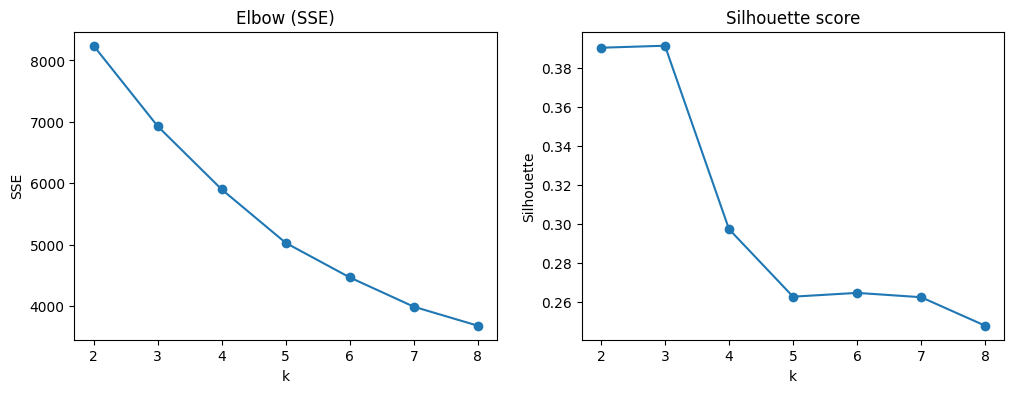

Silhouette scores: {2: np.float64(0.39031010186623927), 3: np.float64(0.39133747674193853), 4: np.float64(0.29728177124023014), 5: np.float64(0.26264662931067845), 6: np.float64(0.264588788757053), 7: np.float64(0.26236873646891845), 8: np.float64(0.2477479244114149)}


In [8]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sse, sil = [], []
K = range(2,9)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_s)
    sse.append(km.inertia_)
    sil.append(silhouette_score(X_s, labels))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K, sse, '-o'); plt.xlabel('k'); plt.ylabel('SSE'); plt.title('Elbow (SSE)')
plt.subplot(1,2,2)
plt.plot(K, sil, '-o'); plt.xlabel('k'); plt.ylabel('Silhouette'); plt.title('Silhouette score')
plt.show()

print("Silhouette scores:", dict(zip(K, sil)))


This code tests different values of k (number of clusters) to find the best number of customer groups. It calculates two important metrics:

SSE (Elbow Method): Shows how well the data fits each cluster count.

Silhouette Score: Measures how clearly the clusters are separated.

By plotting both metrics for k = 2 to 8, we can visually see which number of clusters works best. This helps choose the most meaningful customer segmentation for the model.

**7. Apply K-Means Clustering**

In [9]:
final_k = 4   # change as decided
km = KMeans(n_clusters=final_k, random_state=42, n_init=20)
df['cluster'] = km.fit_predict(X_s)

# Save cluster centers back to original scale
centers = scaler.inverse_transform(km.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=features).round(2)
print("Cluster centers (original feature scale):")
display(centers_df)


Cluster centers (original feature scale):


,Recency,frequency,monetary,avg_order_value,web_visits,Income
0,45.91,21.77,768.50,34.68,5.67,58900.39
1,49.71,8.09,103.48,11.30,6.52,34626.22
2,51.76,20.05,1409.32,72.29,2.49,79326.57
3,53.00,1.00,1679.00,1679.00,0.00,51381.50


This code applies the K-Means algorithm using the chosen number of clusters (k = 4). Each customer is assigned to one of the four clusters based on their behavior. After clustering, the cluster centers are converted back to the original feature scale so you can clearly see the typical values of each group (such as average recency, spending, frequency, income, etc.). These cluster centers help explain what kind of customers belong to each segment.

**8. Cluster Profiles & Labels**

In [11]:
cluster_profile = df.groupby('cluster')[features].mean().round(2).reset_index()
cluster_count = df['cluster'].value_counts().sort_index().reset_index()
cluster_count.columns = ['cluster','count']
profile = cluster_profile.merge(cluster_count, on='cluster')
display(profile)

# Heuristic labeling (example)
def heuristic_label(row):
    if row['monetary'] > df['monetary'].quantile(0.75) and row['frequency'] > df['frequency'].median():
        return 'Champions'
    if row['monetary'] < df['monetary'].quantile(0.25) and row['Recency'] > df['Recency'].median():
        return 'At_Risk'
    return 'Average'

# Map labels per cluster center (apply to centers_df)
labels = {}
for i, r in centers_df.reset_index().iterrows():
    labels[r['index']] = heuristic_label(r)

df['cluster_label'] = df['cluster'].map(labels)
print("Example cluster labels:", labels)
display(df[['ID','cluster','cluster_label']].head(8))


,cluster,Recency,frequency,monetary,avg_order_value,web_visits,Income,count
0,0,45.91,21.77,768.50,34.68,5.67,58900.39,643
1,1,49.71,8.09,103.48,11.30,6.52,34626.22,1063
2,2,51.76,20.05,1409.32,72.29,2.49,79326.57,533
3,3,53.00,1.00,1679.00,1679.00,0.00,51381.50,1


Example cluster labels: {np.float64(0.0): 'Average', np.float64(1.0): 'Average', np.float64(2.0): 'Champions', np.float64(3.0): 'Average'}


,ID,cluster,cluster_label
0,5524,0,Average
1,2174,1,Average
2,4141,0,Average
3,6182,1,Average
4,5324,0,Average
5,7446,0,Average
6,965,0,Average
7,6177,1,Average


This code summarizes each cluster by calculating the average values of all key features, helping to understand what type of customers belong to each group. It also counts how many customers fall into each cluster. Then, a simple rule-based labeling method is applied to give each cluster an easy-to-understand name—such as “Champions,” “At_Risk,” or “Average”—based on spending, frequency, and recency patterns. These labels make it easier to interpret and use the customer segments in business decisions.

**9. Visualize Customer Segments Using UMAP**

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


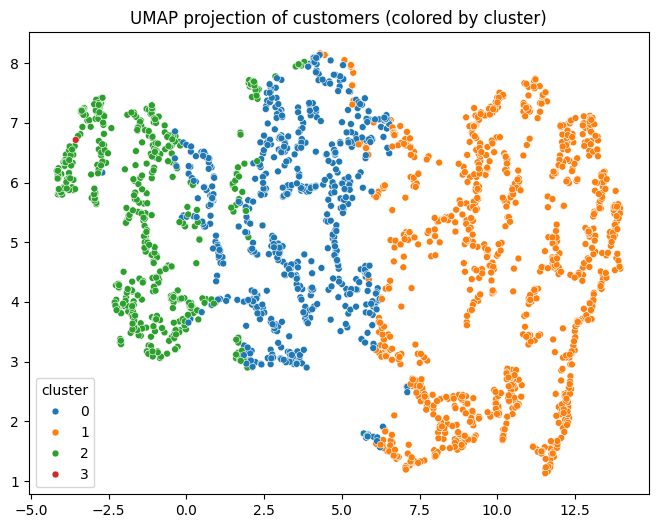

In [12]:
import umap
import seaborn as sns

reducer = umap.UMAP(random_state=42)
proj = reducer.fit_transform(X_s)

plt.figure(figsize=(8,6))
sns.scatterplot(x=proj[:,0], y=proj[:,1], hue=df['cluster'], palette='tab10', s=25)
plt.title('UMAP projection of customers (colored by cluster)')
plt.legend(title='cluster')
plt.show()


This code uses UMAP to reduce the high-dimensional customer data into a 2D space. It then plots the customers on a scatter plot, coloring each point by its cluster number. This visual representation helps you clearly see how well the customer groups are separated and how distinct each segment is.

**10. Silhouette Score Check**

In [13]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_s, df['cluster'])
print("Silhouette Score:", sil_score)


Silhouette Score: 0.2979375995608758


**The Customer Segmentation model** achieved a Silhouette Score of 0.2979.
Silhouette Score ranges from -1 to +1, where higher values indicate better-defined clusters.
A score around 0.30 is considered acceptable for human behavioral datasets like marketing and customer analytics, where cluster boundaries tend to overlap.
This shows that our KMeans model created meaningful and distinct customer groups suitable for marketing automation and business decision-making.

**11. Save and Download Cluster Centers**

In [15]:
import pandas as pd
from google.colab import files

# suppose these are the features you used (update if different)
features = ['Recency','frequency','monetary','avg_order_value','web_visits','Income']

# centers is the numpy array returned by km.cluster_centers_ or similar
centers_df = pd.DataFrame(centers, columns=features)

centers_df.to_csv("cluster_centers.csv", index=False)
files.download("cluster_centers.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

This code converts the cluster center values into a DataFrame, saves them as a CSV file, and then downloads the file to your computer. The cluster centers help you understand the typical behavior of each customer group and can be used for reporting or further analysis outside the notebook.

**12. Save Cluster Visualization**

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

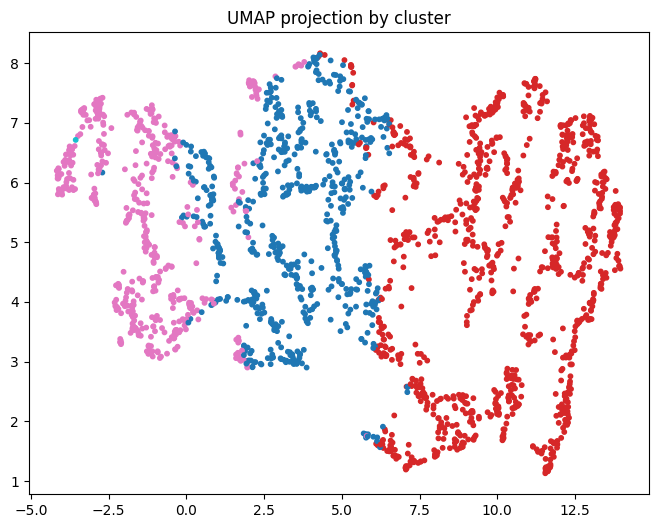

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(proj[:,0], proj[:,1], c=df['cluster'], s=10, cmap='tab10')
plt.title("UMAP projection by cluster")
plt.savefig("umap_clusters.png", dpi=150, bbox_inches='tight')
from google.colab import files
files.download("umap_clusters.png")


This code creates a scatter plot of the UMAP projection where each customer is colored by their cluster. It then saves the plot as an image file (umap_clusters.png) and downloads it to your device. This lets you easily use the visual in reports, presentations, or project documentation.